# Tutorial . Análisis Básico de Electrooculograma con la clase EM  . 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM

## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Clase EM ](#EM)

[2.1 Ejemplo de objeto EOG con sus métodos ](#CO)

[2.1.2 Registro de movimientos laterales](#RML)

[3. Resultados](#R)






## Introducción

El objetivo de este tutorial es mostrar cómo utilizar la clase EM (Electromiograma) para realizar un análisis específico de señales de Electrooculograma (EOG). Para ello, al igual que en el caso del análisis de EKG, se utilizará el atributo tipo, el cual nos permitirá adaptar e integrar métodos diseñados exclusivamente para el estudio del EOG.

A lo largo del tutorial se presentarán ejemplos básicos de uso, así como la resolución de algunas preguntas clave relacionadas con el comportamiento ocular, tales como:

	a)	¿Cómo podemos determinar la duración de los movimientos oculares?
    
	b)	¿Cuánto tiempo transcurre entre un movimiento y otro?
    
	c)	¿Qué tan veloz fue el desplazamiento ocular?

Estas preguntas guiarán el desarrollo del análisis, permitiendo una interpretación más profunda de los patrones oculares presentes en el registro.
    

<a id='introduction'></a>
## Inicialización del Notebook

Primero prepararemos el entorno adecuado para el notebook

In [1]:
# Librerias
import numpy as np
import random as rd
import wave
import sys
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy.signal import butter, lfilter, filtfilt #fFiltrado de datos
from statistics import stdev
import scipy.stats as scs 
import seaborn as sns
import pandas as pd
sys.path.insert(1, r'./../functions') 

# Gráficas
%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 16 
plt.rcParams['axes.titlesize'] = 18 
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 1.4 

<a id='EM'></a>
## Clase EM

In [2]:
class EM: #Creamos la Clase de ECG
    
    def __init__(self, archivo=None, señal=None, tasa_muestra=None,tipo="EMG"): #Como crear un objeto de esta clase
        self.tipo = tipo  # Se añade un atributo para el tipo de electromiograma
        if archivo:
            # Si se pasa un archivo, cargarlo
            self.cargar_archivo(archivo)
        elif señal is not None and tasa_muestra is not None:
            # Si se pasa directamente la señal y la frecuencia de muestreo
            self.señal= señal
            self.tasa_muestra = tasa_muestra
            self.vector_tiempo = self.crear_vector_tiempo()
        else:
            raise ValueError("Debes proporcionar un archivo o la señal y frecuencia de muestreo.")
    
    def cargar_archivo(self, archivo):
        with wave.open(archivo, 'rb') as muestra:
            # Extraer el número de canales, la tasa de muestreo y los datos
            num_canales =  muestra.getnchannels()  # Número de canales
            N = muestra.getnframes()  # Número de frames
            self.tasa_muestra = muestra.getframerate()  # Tasa de muestreo

            # Extraer datos de la grabación .wav
            dstr = muestra.readframes(N * num_canales)
            self.señal = np.frombuffer(dstr, np.int16) #Lo que era waveData antes

            # Crear el vector de tiempo basado en la señal y la frecuencia de muestreo
            self.vector_tiempo = self.crear_vector_tiempo()

            # Imprimir información relevante
            print(f'El registro tiene {num_canales} canal(es).')
            print(f'La frecuencia de muestreo de la grabación es {self.tasa_muestra} Hz.')

    def crear_vector_tiempo(self):
        return np.linspace(0, len(self.señal) / self.tasa_muestra, num=len(self.señal))

    def set_tipo(self, tipo):
    
        self.tipo = tipo

    def get_tipo(self):
        
        return self.tipo

######### Métodos Generales

    def visualizar(self,xmin,xmax):
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))  # Tamaño más compacto y elegante
        
        # Graficar los datos
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')

        # Añadir título y etiquetas
        ax1.set_title('Datos del Registro', fontsize=22, fontweight='bold', color='darkblue')  # Título en negrita y azul
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')  # Eje X con color
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')  # Eje Y con color

        # Ajustar los límites según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')  # Mejorar tamaño y color de los ticks

        # Agregar una cuadrícula (grid) con un estilo suave
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')

        # Mostrar leyenda con los límites del eje x
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        # Mostrar la gráfica
        plt.tight_layout()  # Ajustar el diseño automáticamente para que no se corten los elementos
        plt.show()
        
    def Señal_filtrada_Bandpass(self,low_cutoff,high_cutoff):

        b, a = butter(2, [low_cutoff / (self.tasa_muestra / 2), high_cutoff / (self.tasa_muestra / 2)], btype='bandpass')
        Señal_bandpass = filtfilt(b, a, self.señal)
    
        return Señal_bandpass
        
    def visualizar_filtrada(self, xmin, xmax, low_cutoff, high_cutoff):
        # Obtener la señal filtrada
        señal_filtrada = self.Señal_filtrada_Bandpass(low_cutoff, high_cutoff)
        
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Graficar la señal cruda (con opacidad reducida) y la señal filtrada
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM Cruda', alpha=0.5)
        ax1.plot(self.vector_tiempo, señal_filtrada, color='darkred', linewidth=2, label='Señal EM Filtrada')
        
        # Añadir título y etiquetas
        ax1.set_title('Datos Crudos vs. Filtrado usando BP', fontsize=22, fontweight='bold', color='darkblue')
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')

        # Ajustar los límites del eje x según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        plt.tight_layout()
        plt.show()
        
    def aproxDer(self): 
        V = np.array(self.señal)  # Convertimos los datos a un array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 2:
            return np.zeros(N)  # Si hay menos de 2 elementos, no se puede derivar
    
        derivadas = np.zeros(N)  # Inicializamos un array del mismo tamaño
    
        if N > 2:
            # Derivada central para los puntos intermedios
            derivadas[1:-1] = (V[2:] - V[:-2]) / (2 * DT)
    
        # Derivada hacia adelante en el primer punto
        derivadas[0] = (V[1] - V[0]) / DT
    
        # Derivada hacia atrás en el último punto
        derivadas[-1] = (V[-1] - V[-2]) / DT

        return derivadas
        
    def aprox_2Der(self):

        V = np.array(self.señal)  # Convertir a array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 3:
            return np.zeros(N)  # No es posible calcular la segunda derivada con menos de 3 puntos
    
        derivadas2 = np.zeros(N)
    
        # Derivada central para puntos intermedios:
        # f''(x) ≈ (f(x+DT) - 2 f(x) + f(x-DT)) / DT²
        derivadas2[1:-1] = (V[2:] - 2 * V[1:-1] + V[:-2]) / (DT ** 2)
    
        # Para el primer y último punto usamos aproximaciones hacia adelante y hacia atrás:
        derivadas2[0] = (V[2] - 2 * V[1] + V[0]) / (DT ** 2)
        derivadas2[-1] = (V[-1] - 2 * V[-2] + V[-3]) / (DT ** 2)
    
        return derivadas2
    
    def visualizar_histograma(self, bins=50, color='skyblue', alpha=0.7, mostrar_kde=False):

        plt.figure(figsize=(10, 6))

        # Graficar el histograma con la opción de mostrar o no la KDE
        sns.histplot(self.señal, bins=bins, color=color, alpha=alpha, kde=mostrar_kde)

        plt.title('Histograma de la Señal', fontsize=22)
        plt.xlabel('Voltaje ($\mu$V)', fontsize=16)
        plt.ylabel('Frecuencia', fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')

        plt.tight_layout()
        plt.show()
        
    def Descrip_est(self):
        # Usar scipy.stats.describe para obtener el resumen estadístico de la señal
        stats = scs.describe(self.señal)
        
        # Desglosar los valores obtenidos
        nobs = stats.nobs          # Número de observaciones
        minmax = stats.minmax      # Mínimo y máximo de la señal
        mean = float(stats.mean)   # Convertir a tipo float
        variance = float(stats.variance)  # Convertir a tipo float
        skewness = float(stats.skewness)  # Convertir a tipo float
        kurtosis = float(stats.kurtosis)  # Convertir a tipo float
        
        # Mostrar los resultados de manera limpia
        print(f"Resumen Estadístico de la Señal EM:")
        print(f"  - Número de observaciones: {nobs}")
        print(f"  - Mínimo y máximo: {minmax}")
        print(f"  - Media: {mean:.4f}")  # Mostrar con 4 decimales
        print(f"  - Varianza: {variance:.4f}")  # Mostrar con 4 decimales
        print(f"  - Asimetría: {skewness:.4f}")  # Mostrar con 4 decimales
        print(f"  - Curtosis: {kurtosis:.4f}")  # Mostrar con 4 decimales

    # Método para discriminar por amplitud
    def discriminar_por_amplitud(self, umbral=400):
        # Crear un DataFrame con la señal y su tiempo
        df = pd.DataFrame({'Tiempo': self.vector_tiempo, 'Amplitud': self.señal})
        
        # Filtrar el DataFrame por amplitudes mayores al umbral
        filtered = df[df["Amplitud"] > umbral]
        
        # Mostrar la gráfica de las amplitudes mayores al umbral
        plt.figure(figsize=(12, 6))
        plt.plot(filtered['Tiempo'], filtered['Amplitud'], color='dodgerblue', linewidth=1.5)
        plt.title(f'Señal Filtrada por Amplitud > {umbral} $\mu$V', fontsize=22, fontweight='bold', color='darkblue')
        plt.xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        plt.ylabel('Amplitud ($\mu$V)', fontsize=16, color='darkgreen')
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()
        
        return filtered  # Devuelve el DataFrame filtrado

    # Método para dividir la señal en ventanas de tiempo
    def ventana_1_canal(self, x, npoints):
        single_chan_wind = []
        tot_points = len(x)  # Número total de puntos en la serie
        L = npoints

        nwind = tot_points // npoints  # Número de ventanas

        for h in range(0, nwind):
            t = x[h * L:L * (1 + h)]  # Separar en ventanas
            single_chan_wind.append(t)  # Guardar las ventanas

        return single_chan_wind

    # Método para calcular la varianza en cada ventana de tiempo
    def varianza_ventana_1_canal(self, x, npoints):
        tot_points = len(x)  # Número total de puntos
        nwind = tot_points // npoints  # Número de ventanas
        wind_x = self.ventana_1_canal(x, npoints)  # Llamada a la función para obtener las ventanas
        
        # Calcular la varianza de cada ventana
        v_single_chan_wind = [np.var(wind_x[w]) for w in range(0, nwind)]
        
        return v_single_chan_wind

    # Método para visualizar la varianza de la señal en ventanas de tiempo
    def visualizar_varianza(self, npoints=50000):
        # Normalizar la varianza para una mejor visualización
        varianza = self.varianza_ventana_1_canal(self.señal, npoints)
        varianza_normalizada = np.array(varianza) / max(varianza)

        # Crear la figura
        plt.figure(figsize=(20, 5), dpi=100)
        plt.title('Varianza del EM en ventanas de tiempo')
        plt.xlabel('Ventana de tiempo')
        plt.ylabel('Varianza')

        # Graficar la varianza normalizada
        plt.plot(varianza_normalizada)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()    

    def detecta_maximos_locales(self, threshold_ratio=0.7):
    # If not all the R peaks are detected, lower the threshold_ratio
    # If components that are not R peaks (like T waves) are detected, higher the threshold_ratio

        if len(self.vector_tiempo) != len(self.señal): #Raises an error if the two arrays have different lengths
            raise Exception("The two arrays have different lengths.")
    
        interval = max(self.señal) - min(self.señal)
        threshold = threshold_ratio*interval + min(self.señal)
        maxima = []
        maxima_indices = []
        mxs_indices = []
        banner = False
    
        for i in range(0, len(self.señal)):
            
            if self.señal[i] >= threshold:#If a threshold value is surpassed,
                # the indices and values are saved 
                banner = True
                maxima_indices.append(i)
                maxima.append(self.señal[i])
            
            elif banner == True and self.señal[i] < threshold: #If the threshold value is crossed
                # the index of the maximum value in the original array is saved
                index_local_max = maxima.index(max(maxima))
                mxs_indices.append(maxima_indices[index_local_max])
                maxima = []
                maxima_indices = []
                banner = False     

        return mxs_indices
    
    def cortar_segmento(self, t_inicio, t_fin):
 
        if t_inicio < 0 or t_fin > self.vector_tiempo[-1]:
            raise ValueError("Los tiempos de inicio o fin están fuera del rango de la señal.")
    
        # Encontramos los índices correspondientes a los tiempos de inicio y fin
        idx_inicio = np.searchsorted(self.vector_tiempo, t_inicio)
        idx_fin = np.searchsorted(self.vector_tiempo, t_fin)
    
        # Cortamos la señal y el vector de tiempo
        segmento = self.señal[idx_inicio:idx_fin]
        vector_tiempo_segmento = self.vector_tiempo[idx_inicio:idx_fin]
    
        # Creamos un nuevo objeto ECG con el segmento y su vector de tiempo
        nuevo_ecg = EM(señal=segmento, tasa_muestra=self.tasa_muestra)
        nuevo_ecg.vector_tiempo = vector_tiempo_segmento  # Actualizamos el vector de tiempo

        return nuevo_ecg

############# Métodos creados para EOG

    def detectar_picos_por_vecindad(self, P=5, umbral=500):
        # Inicializamos las listas para los índices de los picos positivos y negativos
        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):
            
            picos_positivos = []
            picos_negativos = []
    
            # Usamos un solo recorrido para detectar los picos
            for i in range(P, len(self.señal) - P):
                # Calculamos el máximo y mínimo de la vecindad de tamaño P solo una vez
                vecindad = self.señal[i-P:i+P+1]
                max_vecindad = np.max(vecindad)
                min_vecindad = np.min(vecindad)
    
                # Si el punto actual es el máximo o el mínimo de la vecindad
                if self.señal[i] == max_vecindad and abs(self.señal[i]) > umbral:
                    picos_positivos.append(i)  # Guardamos el índice del pico positivo
                elif self.señal[i] == min_vecindad and abs(self.señal[i]) > umbral:
                    picos_negativos.append(i)  # Guardamos el índice del pico negativo
    
    
            # Crear la figura para la visualización
            fig, ax1 = plt.subplots(figsize=(12, 6))
    
            # Graficar la señal original
            ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')
    
            # Resaltar los picos positivos detectados
            ax1.scatter(self.vector_tiempo[picos_positivos], self.señal[picos_positivos], color='red', zorder=5, label='Picos Positivos')
    
            # Resaltar los picos negativos detectados
            ax1.scatter(self.vector_tiempo[picos_negativos], self.señal[picos_negativos], color='green', zorder=5, label='Picos Negativos')
    
            # Añadir título y etiquetas
            ax1.set_title(f'Detección de Picos por Vecindad (P = {P}, umbral = {umbral})', fontsize=22, fontweight='bold', color='darkblue')
            ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
            ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')
    
            # Ajustar los límites del eje Y para que se ajusten a la señal
            ax1.set_ylim(-max(self.señal), max(self.señal))  # Limitar el eje Y para que se vea la amplitud de la señal
    
            # Mejorar la estética de los ejes
            ax1.tick_params(axis='both', labelsize=12, colors='black')
            ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
            ax1.legend(loc='upper right', fontsize=14)
    
            # Mostrar la gráfica
            plt.tight_layout()
            plt.show()
    
            return [picos_positivos, picos_negativos]

    def encontrar_bordes_vecindad_cero(self,picos_positivos, picos_negativos, P=5, umbral=500):

        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):
            # Inicializamos las listas para los bordes de las vecindades positivas y negativas
            bordes_vecindades_positivos = []
            bordes_vecindades_negativos = []
    
            # Buscar vecindades para picos positivos
            for pico in picos_positivos:
                # Comprobamos si el pico es positivo (señal[pico] debe ser positiva)
                if self.señal[pico] > 0:
                    # Buscar hacia atrás hasta que la señal cruce el cero (de positiva a negativa)
                    inicio_vecindad = pico
                    while self.señal[inicio_vecindad] > 0:
                        inicio_vecindad -= 1
    
                    # Buscar hacia adelante hasta que la señal cruce el cero (de positiva a negativa)
                    fin_vecindad = pico
                    while fin_vecindad < len(self.señal) - 1 and self.señal[fin_vecindad] > 0:
                        fin_vecindad += 1
    
                    bordes_vecindades_positivos.append((inicio_vecindad, fin_vecindad))
    
            # Buscar vecindades para picos negativos
            for pico in picos_negativos:
                # Comprobamos si el pico es negativo (señal[pico] debe ser negativa)
                if self.señal[pico] < 0:
                    # Buscar hacia atrás hasta que la señal cruce el cero (de negativa a positiva)
                    inicio_vecindad = pico
                    while self.señal[inicio_vecindad] < 0:
                        inicio_vecindad -= 1
    
                    # Buscar hacia adelante hasta que la señal cruce el cero (de negativa a positiva)
                    fin_vecindad = pico
                    while fin_vecindad < len(self.señal) - 1 and self.señal[fin_vecindad] < 0:
                        fin_vecindad += 1
    
                    bordes_vecindades_negativos.append((inicio_vecindad, fin_vecindad))
    
    
            # Crear la figura para la visualización
            fig, ax1 = plt.subplots(figsize=(12, 6))
    
            # Graficar la señal original
            ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')
    
            # Resaltar los picos detectados
            ax1.scatter(self.vector_tiempo[picos_positivos], self.señal[picos_positivos], color='red', zorder=5, label='Picos Positivos')
            ax1.scatter(self.vector_tiempo[picos_negativos], self.señal[picos_negativos], color='green', zorder=5, label='Picos Negativos')
    
            # Resaltar la vecindad alrededor de cada pico positivo
            for inicio, fin in bordes_vecindades_positivos:
                ax1.axvspan(self.vector_tiempo[inicio], self.vector_tiempo[fin], color='orange', alpha=0.3)  # Vecindad resaltada en amarillo
    
            # Resaltar la vecindad alrededor de cada pico negativo
            for inicio, fin in bordes_vecindades_negativos:
                ax1.axvspan(self.vector_tiempo[inicio], self.vector_tiempo[fin], color='pink', alpha=0.3)  # Vecindad resaltada en verde claro
    
            # Añadir título y etiquetas
            ax1.set_title(f'Areas donde ocurre un movimiento ocular', fontsize=22, fontweight='bold', color='darkblue')
            ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
            ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')
    
            # Mejorar la estética de los ejes
            ax1.tick_params(axis='both', labelsize=12, colors='black')
            ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
            ax1.legend(loc='upper right', fontsize=14)
    
            # Mostrar la gráfica
            plt.tight_layout()
            plt.show()
    
            return bordes_vecindades_positivos, bordes_vecindades_negativos
        
    def analizar_movimientos_oculares_por_vecindad(self, bordes_positivos, bordes_negativos):
        
        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):
    
            amplitudes = []
            velocidades = []
            duraciones = []
            frecuencias = []
        
            # Unir y eliminar duplicados
            todas_vecindades = list(set(bordes_positivos + bordes_negativos))
            todas_vecindades.sort(key=lambda x: x[0])  # Ordenar por tiempo de inicio
        
            # Eliminar solapamientos exactos consecutivos
            vecindades_filtradas = []
            for i in range(len(todas_vecindades)):
                if i == 0 or todas_vecindades[i] != todas_vecindades[i-1]:
                    vecindades_filtradas.append(todas_vecindades[i])
        
            for i, (inicio, fin) in enumerate(vecindades_filtradas):
                segmento = self.señal[inicio:fin]
                tiempo_inicio = self.vector_tiempo[inicio]
                tiempo_fin = self.vector_tiempo[fin]
        
                amplitud = np.max(segmento) - np.min(segmento)
                duracion = tiempo_fin - tiempo_inicio
                velocidad = amplitud / duracion if duracion != 0 else 0
        
                amplitudes.append(amplitud)
                duraciones.append(duracion)
                velocidades.append(velocidad)
        
                if i > 0:
                    tiempo_anterior = self.vector_tiempo[vecindades_filtradas[i-1][0]]
                    frecuencia = 1 / (tiempo_inicio - tiempo_anterior) if tiempo_inicio - tiempo_anterior != 0 else 0
                else:
                    frecuencia = 0
                frecuencias.append(frecuencia)
        
            df = pd.DataFrame({
                "Inicio (s)": [self.vector_tiempo[i[0]] for i in vecindades_filtradas],
                "Fin (s)": [self.vector_tiempo[i[1]] for i in vecindades_filtradas],
                "Amplitud (uV)": amplitudes,
                "Duración (s)": duraciones,
                "Velocidad (uV/s)": velocidades,
                "Frecuencia (Hz)": frecuencias
            })
        
            print(df.round(3))
            return df
    
    def clasificar_y_visualizar_movimientos(self, df):

        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):
            # 1. Clasificación
            clasificaciones = []
            for i, row in df.iterrows():
                dur = row["Duración (s)"]
                vel = row["Velocidad (uV/s)"]
                amp = row["Amplitud (uV)"]
        
                if dur < 0.08 and amp < 1000:
                    clasificaciones.append("Microsacada")
                elif dur <= 0.6 and vel > 3500 and amp>800:
                    clasificaciones.append("Sacada")
                elif dur >= 0.2 and vel < 3000 and amp < 800:
                    clasificaciones.append("Fijación")
                elif vel > 15000 and amp > 3000 and dur<0.4:
                    clasificaciones.append("Parpadeo")
                else:
                    clasificaciones.append("Indefinido")
        
            df["Tipo de Movimiento"] = clasificaciones
        
            # 2. Conteo y gráfico de pastel
            conteo = df["Tipo de Movimiento"].value_counts()
            print("Conteo de tipos de movimientos:")
            print(conteo)
        
            plt.figure(figsize=(6, 6))
            conteo.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
            plt.title("Distribución de Tipos de Movimiento")
            plt.ylabel('')
            plt.tight_layout()
            plt.show()
        
        
            return df

    def graficar_movimientos_clasificados(self, df):

        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):
            # Colores por tipo
            colores = {
                "Sacada": 'orange',
                "Fijación": 'lightgreen',
                "Microsacada": 'violet',
                "Parpadeo": 'gray',
                "Indefinido": 'lightblue'
            }
        
            fig, ax1 = plt.subplots(figsize=(14, 6))
            ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')
        
            for _, row in df.iterrows():
                inicio = row["Inicio (s)"]
                fin = row["Fin (s)"]
                tipo = row["Tipo de Movimiento"]
                color = colores.get(tipo, 'lightgray')
        
                # Resaltar zona sin texto
                ax1.axvspan(inicio, fin, color=color, alpha=0.4)
        
            # Título y etiquetas
            ax1.set_title("Señal EOG con Clasificación de Movimientos Oculares", fontsize=16, fontweight='bold')
            ax1.set_xlabel("Tiempo (s)", fontsize=14, color='darkgreen')
            ax1.set_ylabel("Voltaje ($\mu$V)", fontsize=14, color='darkgreen')
            ax1.tick_params(axis='both', labelsize=12)
            ax1.grid(True, linestyle='--', alpha=0.6)
        
            # Leyenda de colores
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=colores[k], edgecolor='k', label=k) for k in colores]
            ax1.legend(handles=legend_elements, loc='upper right', title="Tipo de Movimiento", fontsize=10)
        
            plt.tight_layout()
            plt.show()

    def agregar_fijaciones_entre_eventos(self, df_movimientos):

        if(self.tipo!= 'EOG'):
            print('El tipo de registro debe de ser EOG')

        if(self.tipo=='EOG'):        
            nuevas_fijaciones = []
        
            # Ordenar por inicio de evento (por si acaso)
            df_ordenado = df_movimientos.sort_values(by="Inicio (s)").reset_index(drop=True)
        
            for i in range(1, len(df_ordenado)):
                fin_anterior = df_ordenado.loc[i - 1, "Fin (s)"]
                inicio_actual = df_ordenado.loc[i, "Inicio (s)"]
        
                # Si hay un intervalo entre eventos
                if inicio_actual > fin_anterior:
                    segmento = self.señal[
                        np.searchsorted(self.vector_tiempo, fin_anterior) :
                        np.searchsorted(self.vector_tiempo, inicio_actual)
                    ]
                    duracion = inicio_actual - fin_anterior
                    amplitud = np.max(segmento) - np.min(segmento) if len(segmento) > 0 else 0
                    velocidad = amplitud / duracion if duracion != 0 else 0
                    # Evaluar si cumple condiciones típicas de fijación
                    if duracion >= 0.2 and velocidad < 2000 and amplitud < 600:
                        tipo = "Fijación"
                    elif duracion <= 0.4 and velocidad > 10000 and amplitud > 2500:
                        tipo = "Parpadeo"
                    else:
                        tipo = "Indefinido"
                    nuevas_fijaciones.append({
                        "Inicio (s)": fin_anterior,
                        "Fin (s)": inicio_actual,
                        "Amplitud (uV)": amplitud,
                        "Duración (s)": duracion,
                        "Velocidad (uV/s)": velocidad,
                        "Frecuencia (Hz)": 0,
                        "Tipo de Movimiento": tipo
                    })
        
            # Convertir a DataFrame
            df_fijaciones = pd.DataFrame(nuevas_fijaciones)
        
            # Unir con el original
            df_completo = pd.concat([df_movimientos, df_fijaciones], ignore_index=True)
            df_completo = df_completo.sort_values(by="Inicio (s)").reset_index(drop=True)
        
            return df_completo


<a id='C0'></a>
### Ejemplo de objeto EOG 

Para ilustrar la aplicación de los métodos desarrollados, se analizará un registro de Electrooculograma (EOG) que contiene movimientos oculares laterales (de un lado a otro). Este ejemplo permitirá demostrar paso a paso cómo detectar, segmentar y clasificar los eventos presentes en la señal.

<a id='RML'></a>
#### Registro de lado a lado

In [3]:
#Creamos un objeto EOG con un archivo .wav

#En este registro se realizaron movimientos de izquierda a derecha
EOG=EM(archivo='/Users/danielyedra/Desktop/Electro_fisio/electrophys/EOG/EOGbasics/data/S2_EOG_leftRight1.wav',tipo="EOG")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {EOG.señal}")
print(f"Tiempo de la señal: {EOG.vector_tiempo[-1]} segundos")
print(f'Tipo de registro: {EOG.get_tipo()}')
EOG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 10000 Hz.
Señal de la muestra: [ 301  357  362 ... -333 -268 -273]
Tiempo de la señal: 11.4131 segundos
Tipo de registro: EOG
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 114131
  - Mínimo y máximo: (np.int16(-2290), np.int16(3034))
  - Media: 132.3095
  - Varianza: 252084.8223
  - Asimetría: 0.5532
  - Curtosis: 4.5707


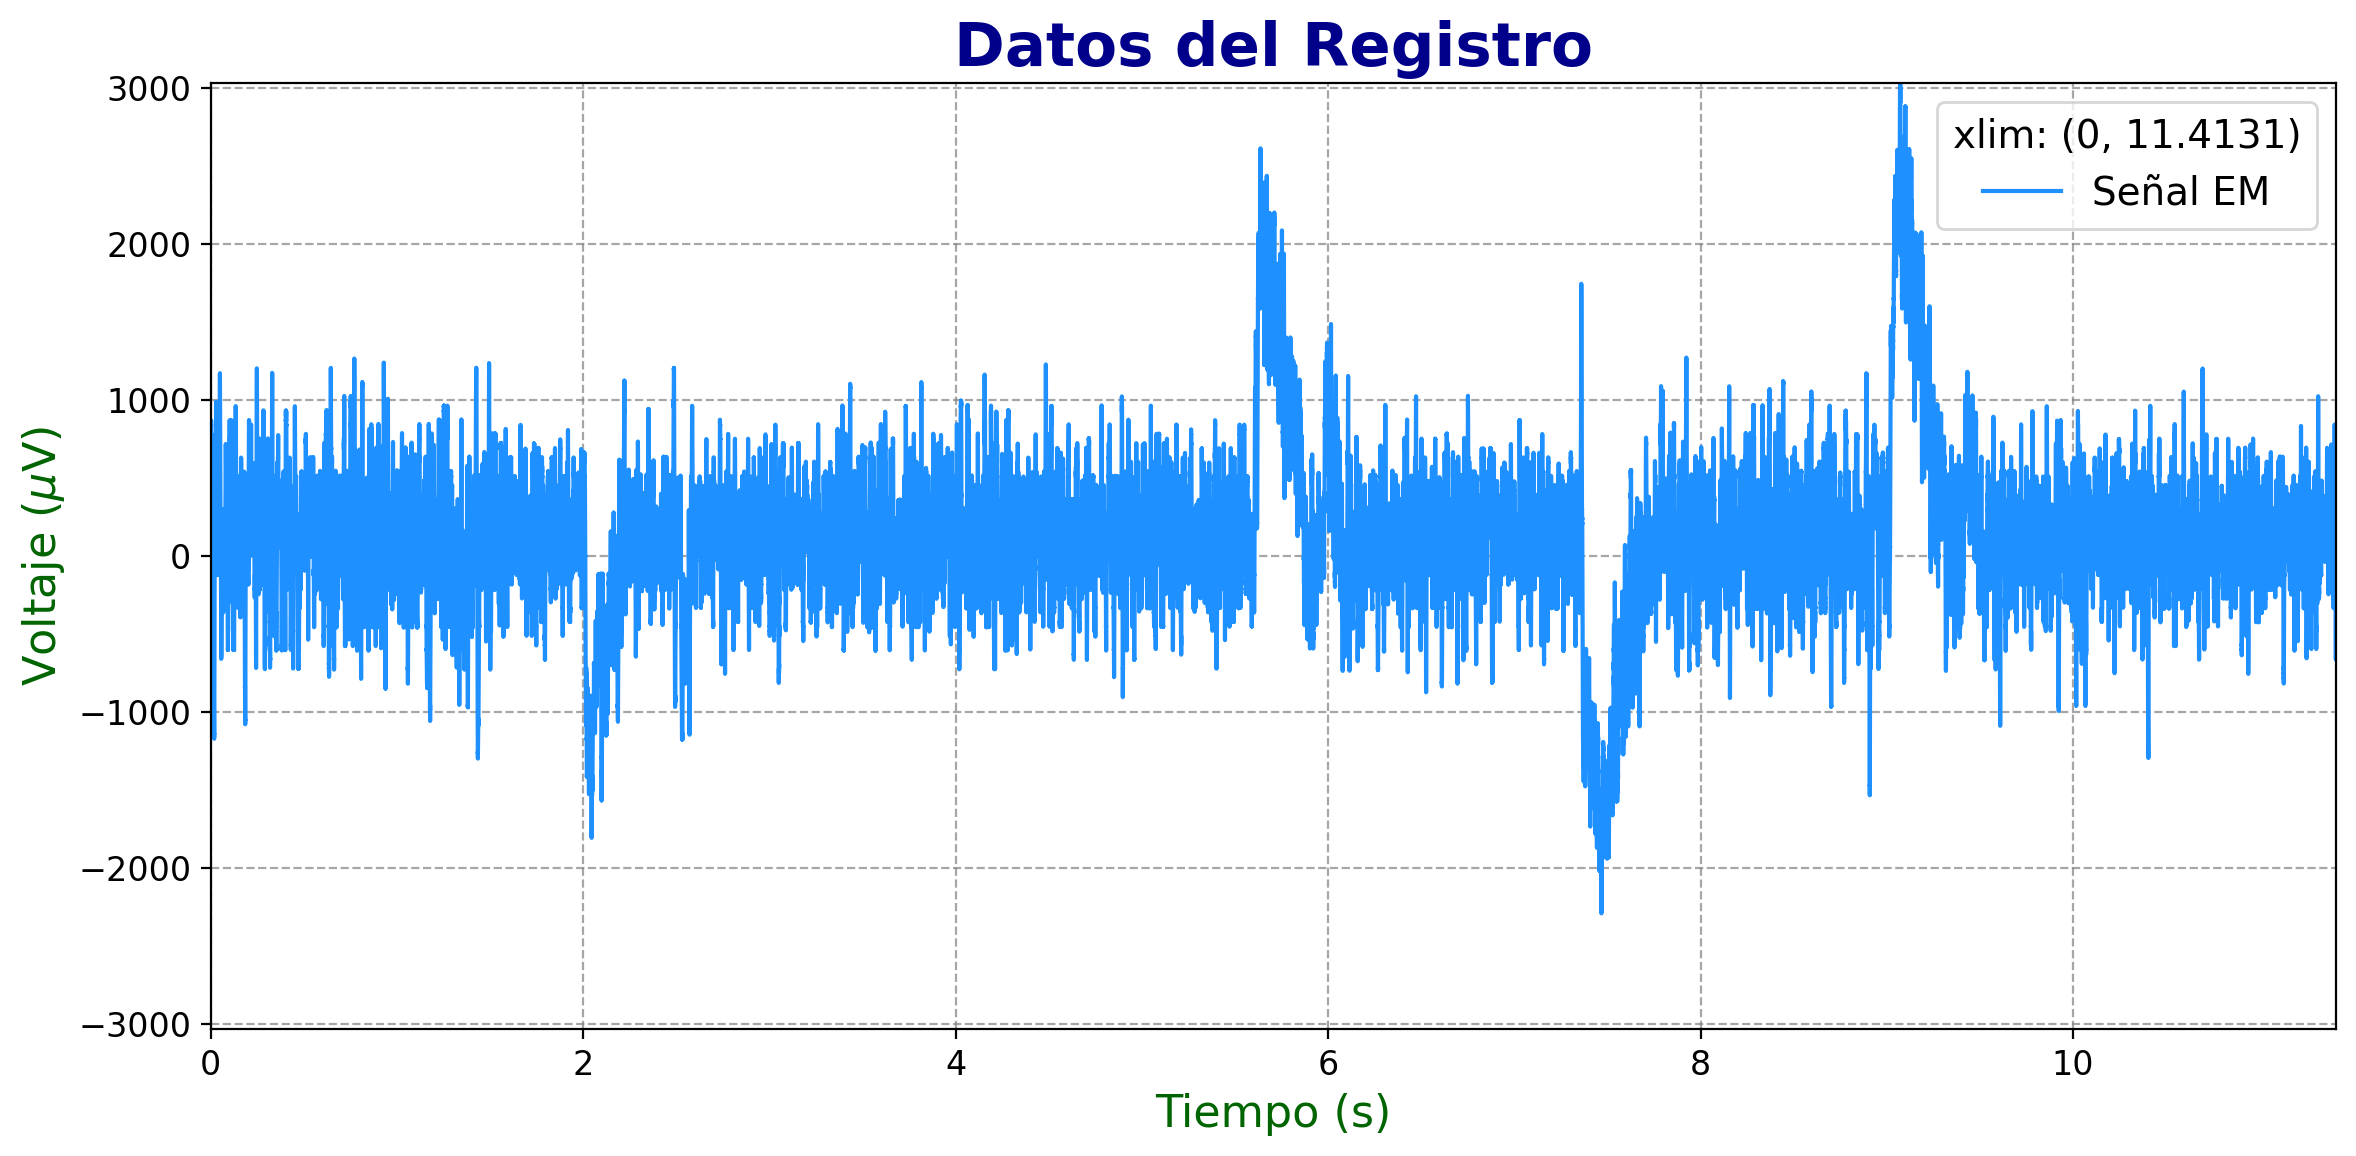

In [4]:
EOG.visualizar(0,max(EOG.vector_tiempo))

Ahora filtraremos el registro con el objetivo de atenuar el ruido presente en la señal, asegurándonos al mismo tiempo de preservar los picos característicos asociados a los movimientos oculares. Este paso es fundamental para mejorar la calidad del análisis y evitar que el ruido afecte la detección y clasificación de eventos.


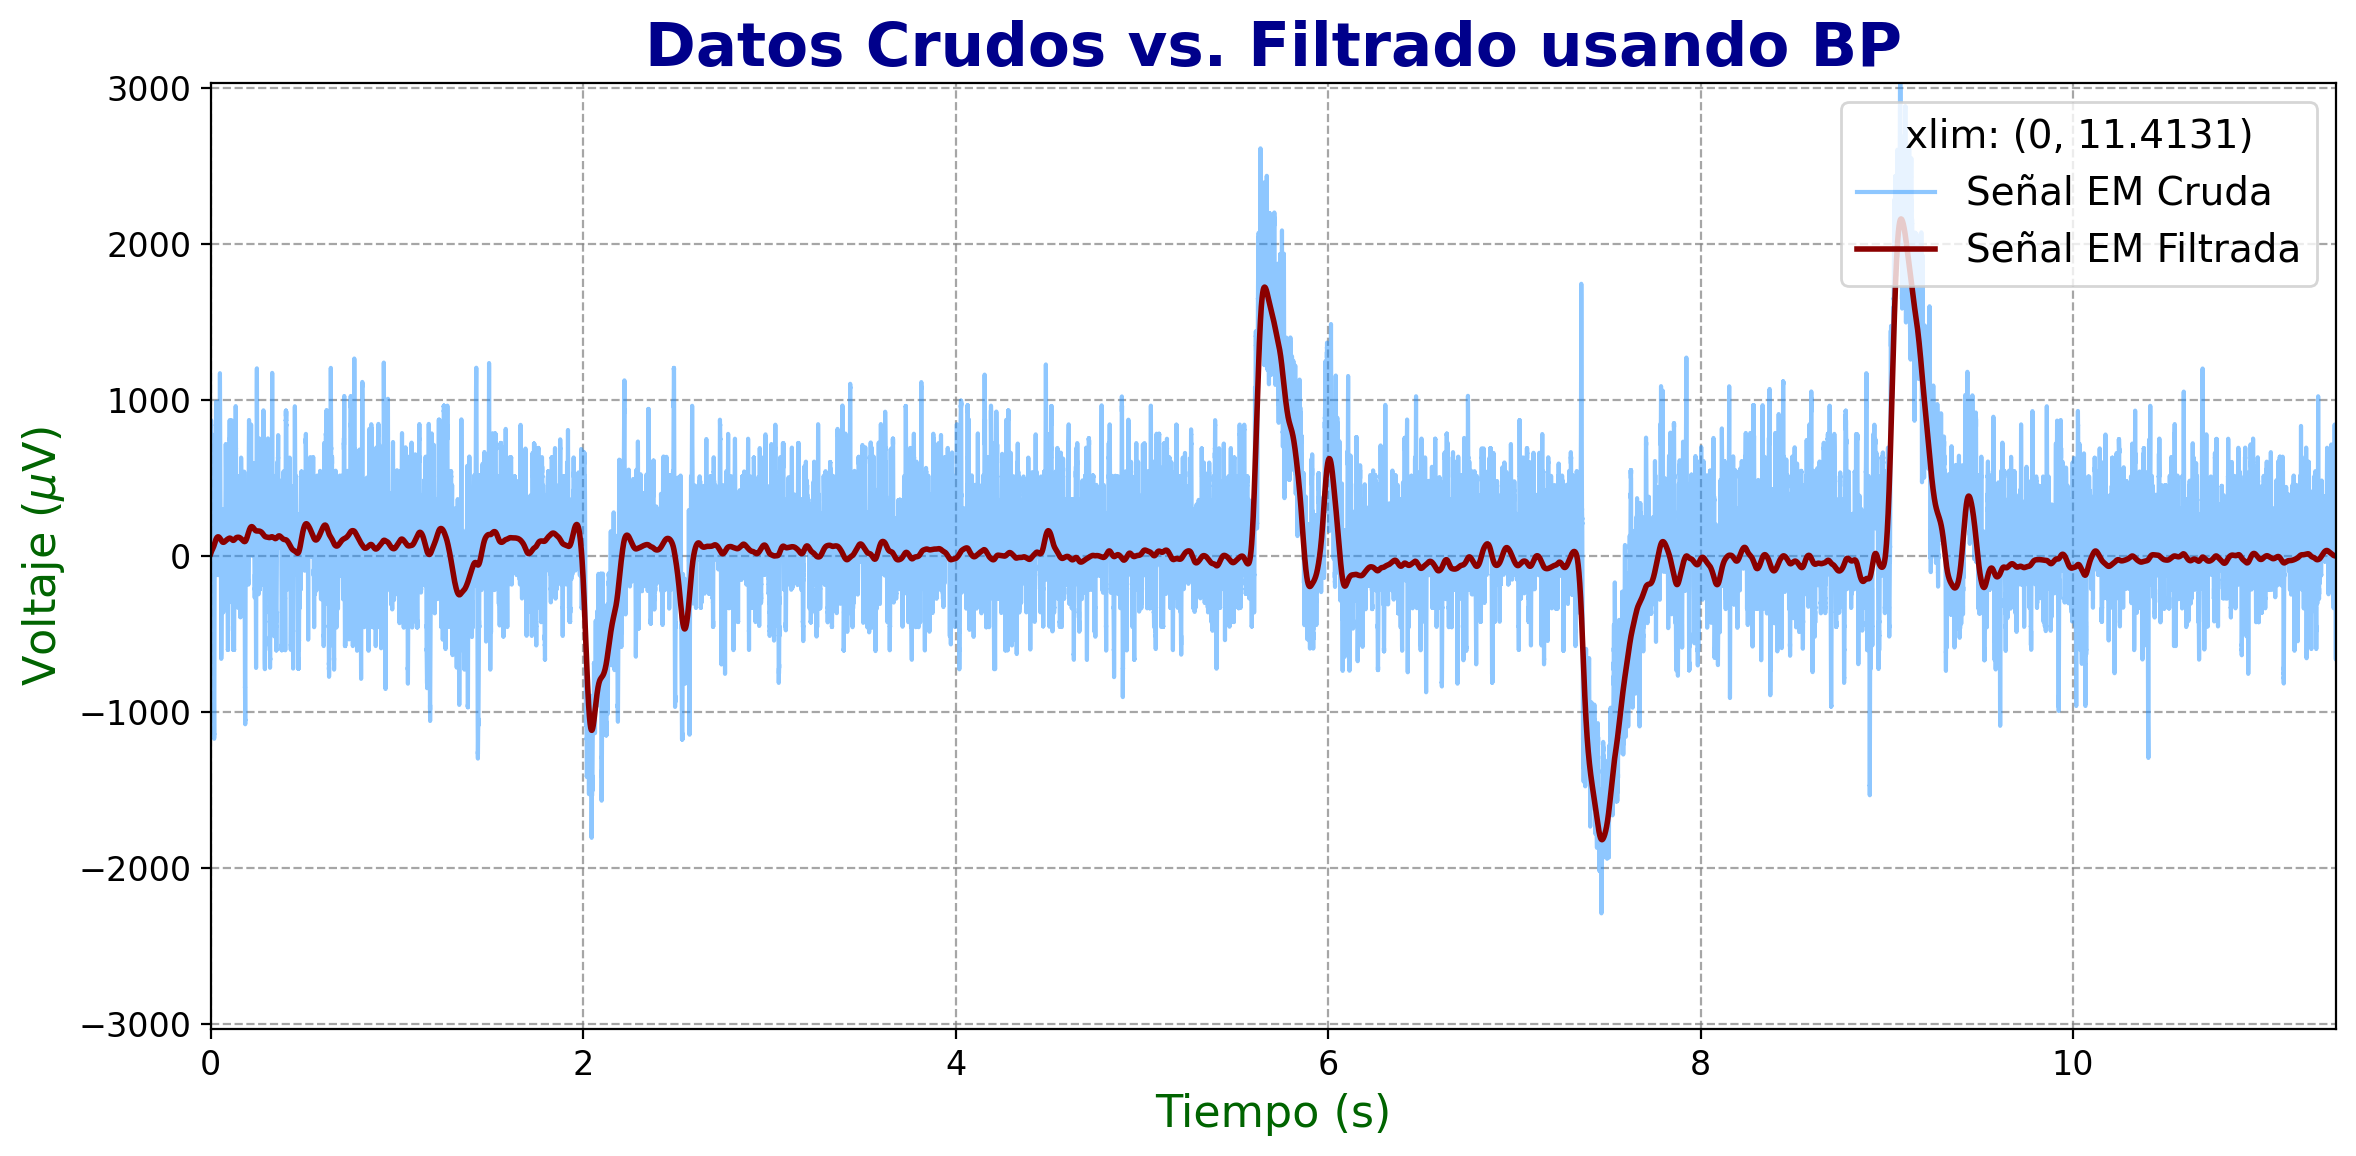

In [5]:
EOG.visualizar_filtrada( 0,max(EOG.vector_tiempo), low_cutoff=0.05, high_cutoff=10)

In [6]:
SF1=EOG.Señal_filtrada_Bandpass(low_cutoff=0.05,high_cutoff=10)
EOG_F=EM(señal=SF1,tasa_muestra=EOG.tasa_muestra,tipo='EOG')

Ahora vamos a utilizar los métodos específicos para el análisis de señales EOG. Antes de comenzar, es importante definir qué consideraremos como movimiento ocular en este contexto. En nuestro caso, un movimiento ocular se identifica como un cambio significativo dentro de una vecindad alrededor de los picos detectados en la señal.

Además, es importante mencionar que durante la creación del registro se siguió la siguiente metodología: tras realizar un movimiento ocular lateral, se mantuvo una fijación antes de regresar la mirada. Esta secuencia permite distinguir claramente entre las sacadas y los intervalos de fijación.

El procedimiento que seguimos se resume en los siguientes pasos:

1.	En primer lugar, se detectan los picos de la señal utilizando el método EOG.detectar_picos_por_vecindad(P=20000, umbral=1200, P_2=1500). Este método identifica los picos de la señal y los clasifica en positivos y negativos, lo cual permite analizar movimientos en ambos sentidos.

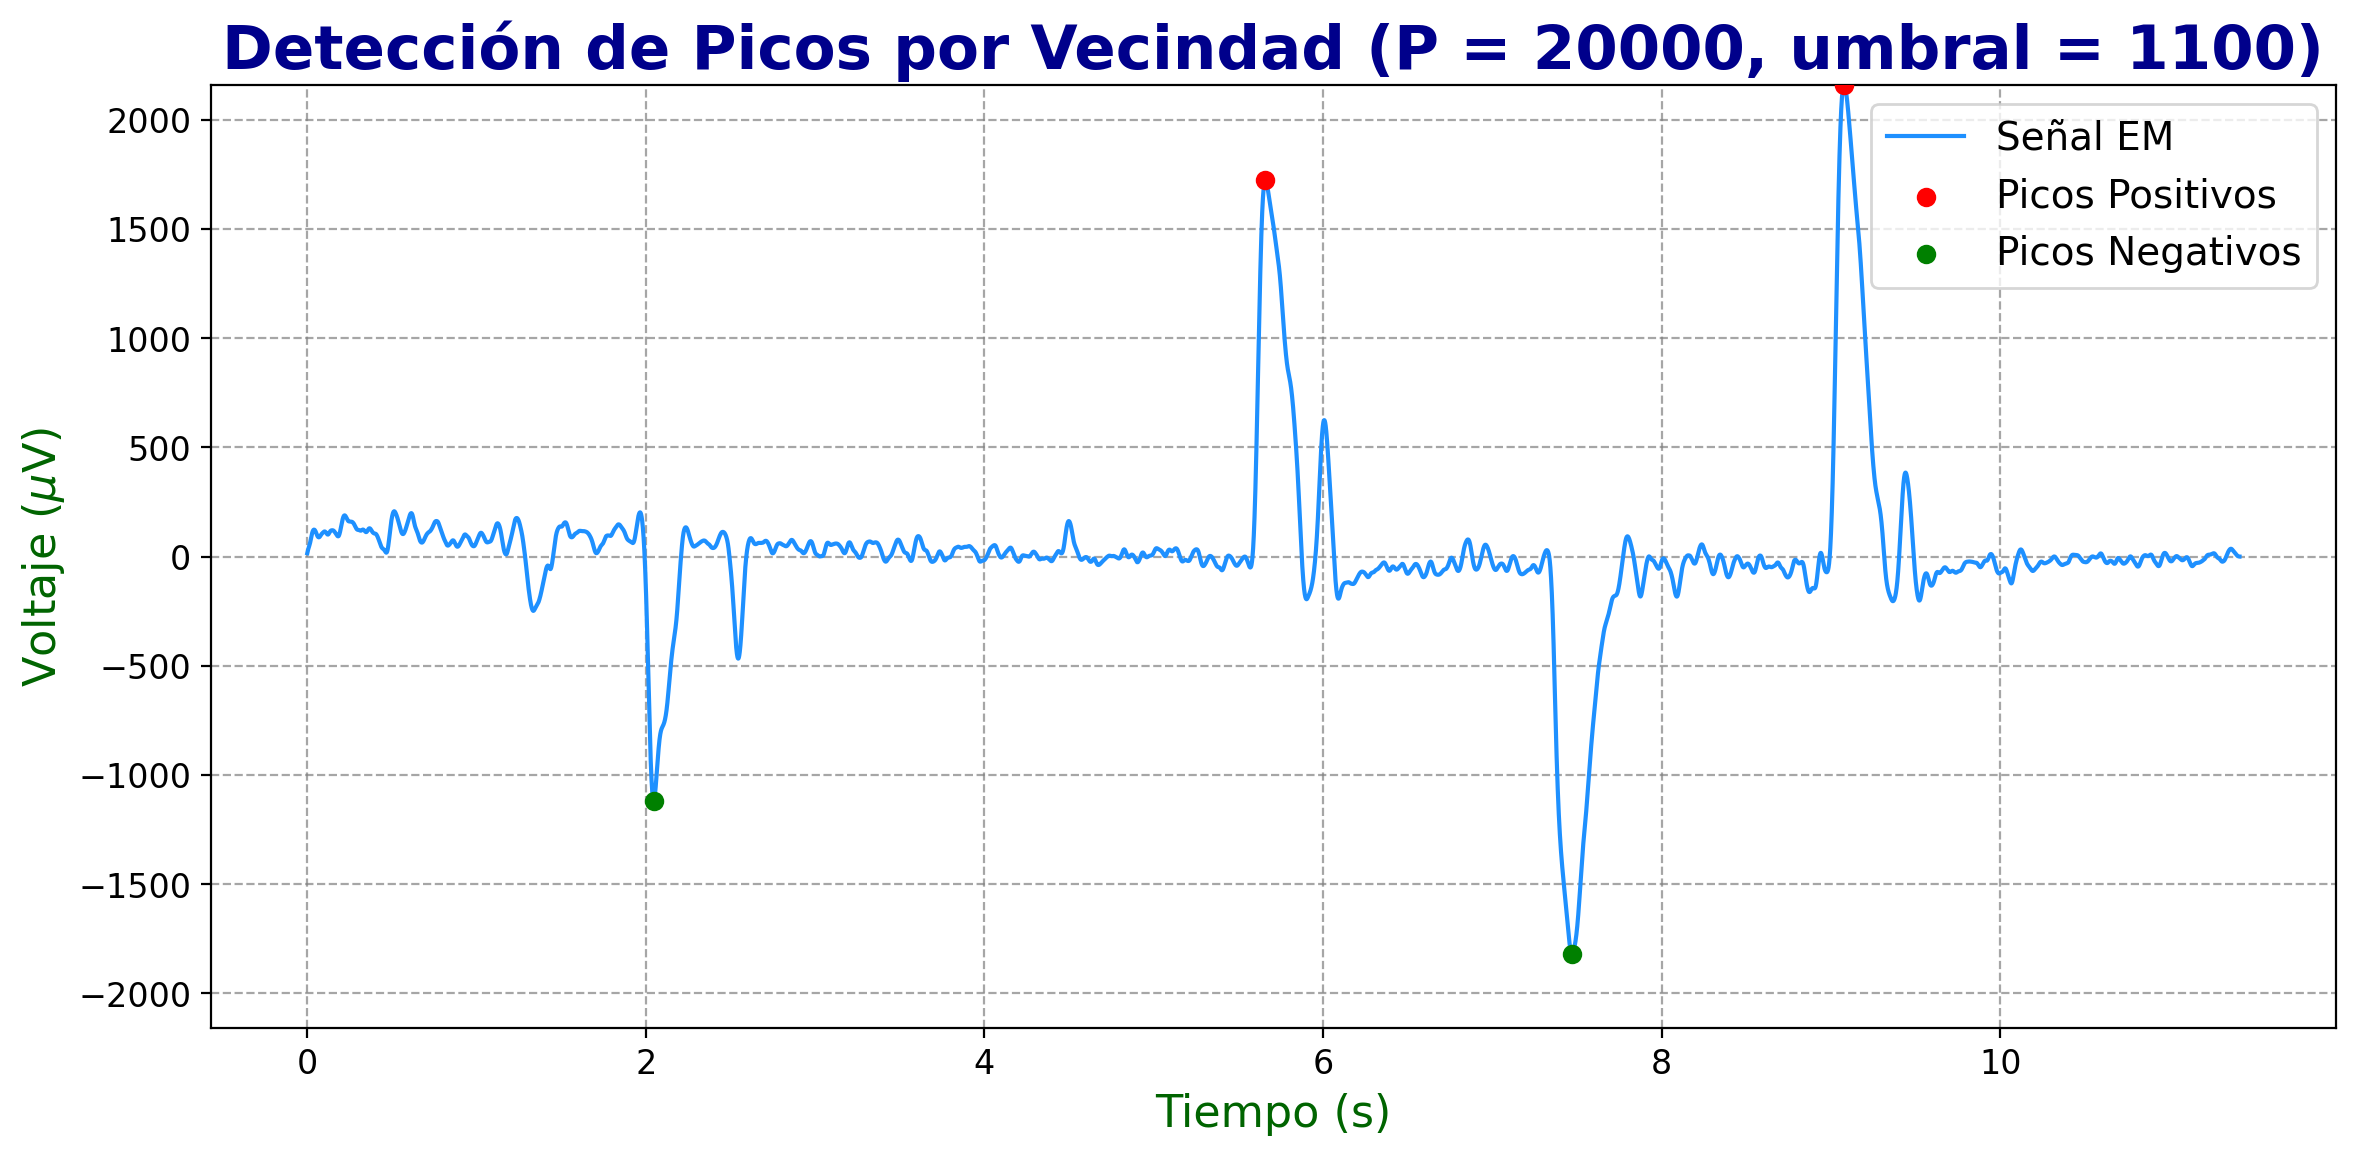

In [7]:
A=EOG_F.detectar_picos_por_vecindad(P=20000, umbral=1100)

2.	Una vez identificados los picos, el siguiente paso consiste en delimitar la vecindad temporal en la que ocurre el movimiento ocular. Existen diversas formas de definir estos intervalos, sin embargo, en este análisis optamos por una estrategia simple, basada en los cruces por cero. Es decir, consideramos que el inicio y fin de un movimiento ocular se encuentran en los puntos donde la señal cruza el eje horizontal alrededor de cada pico detectado.

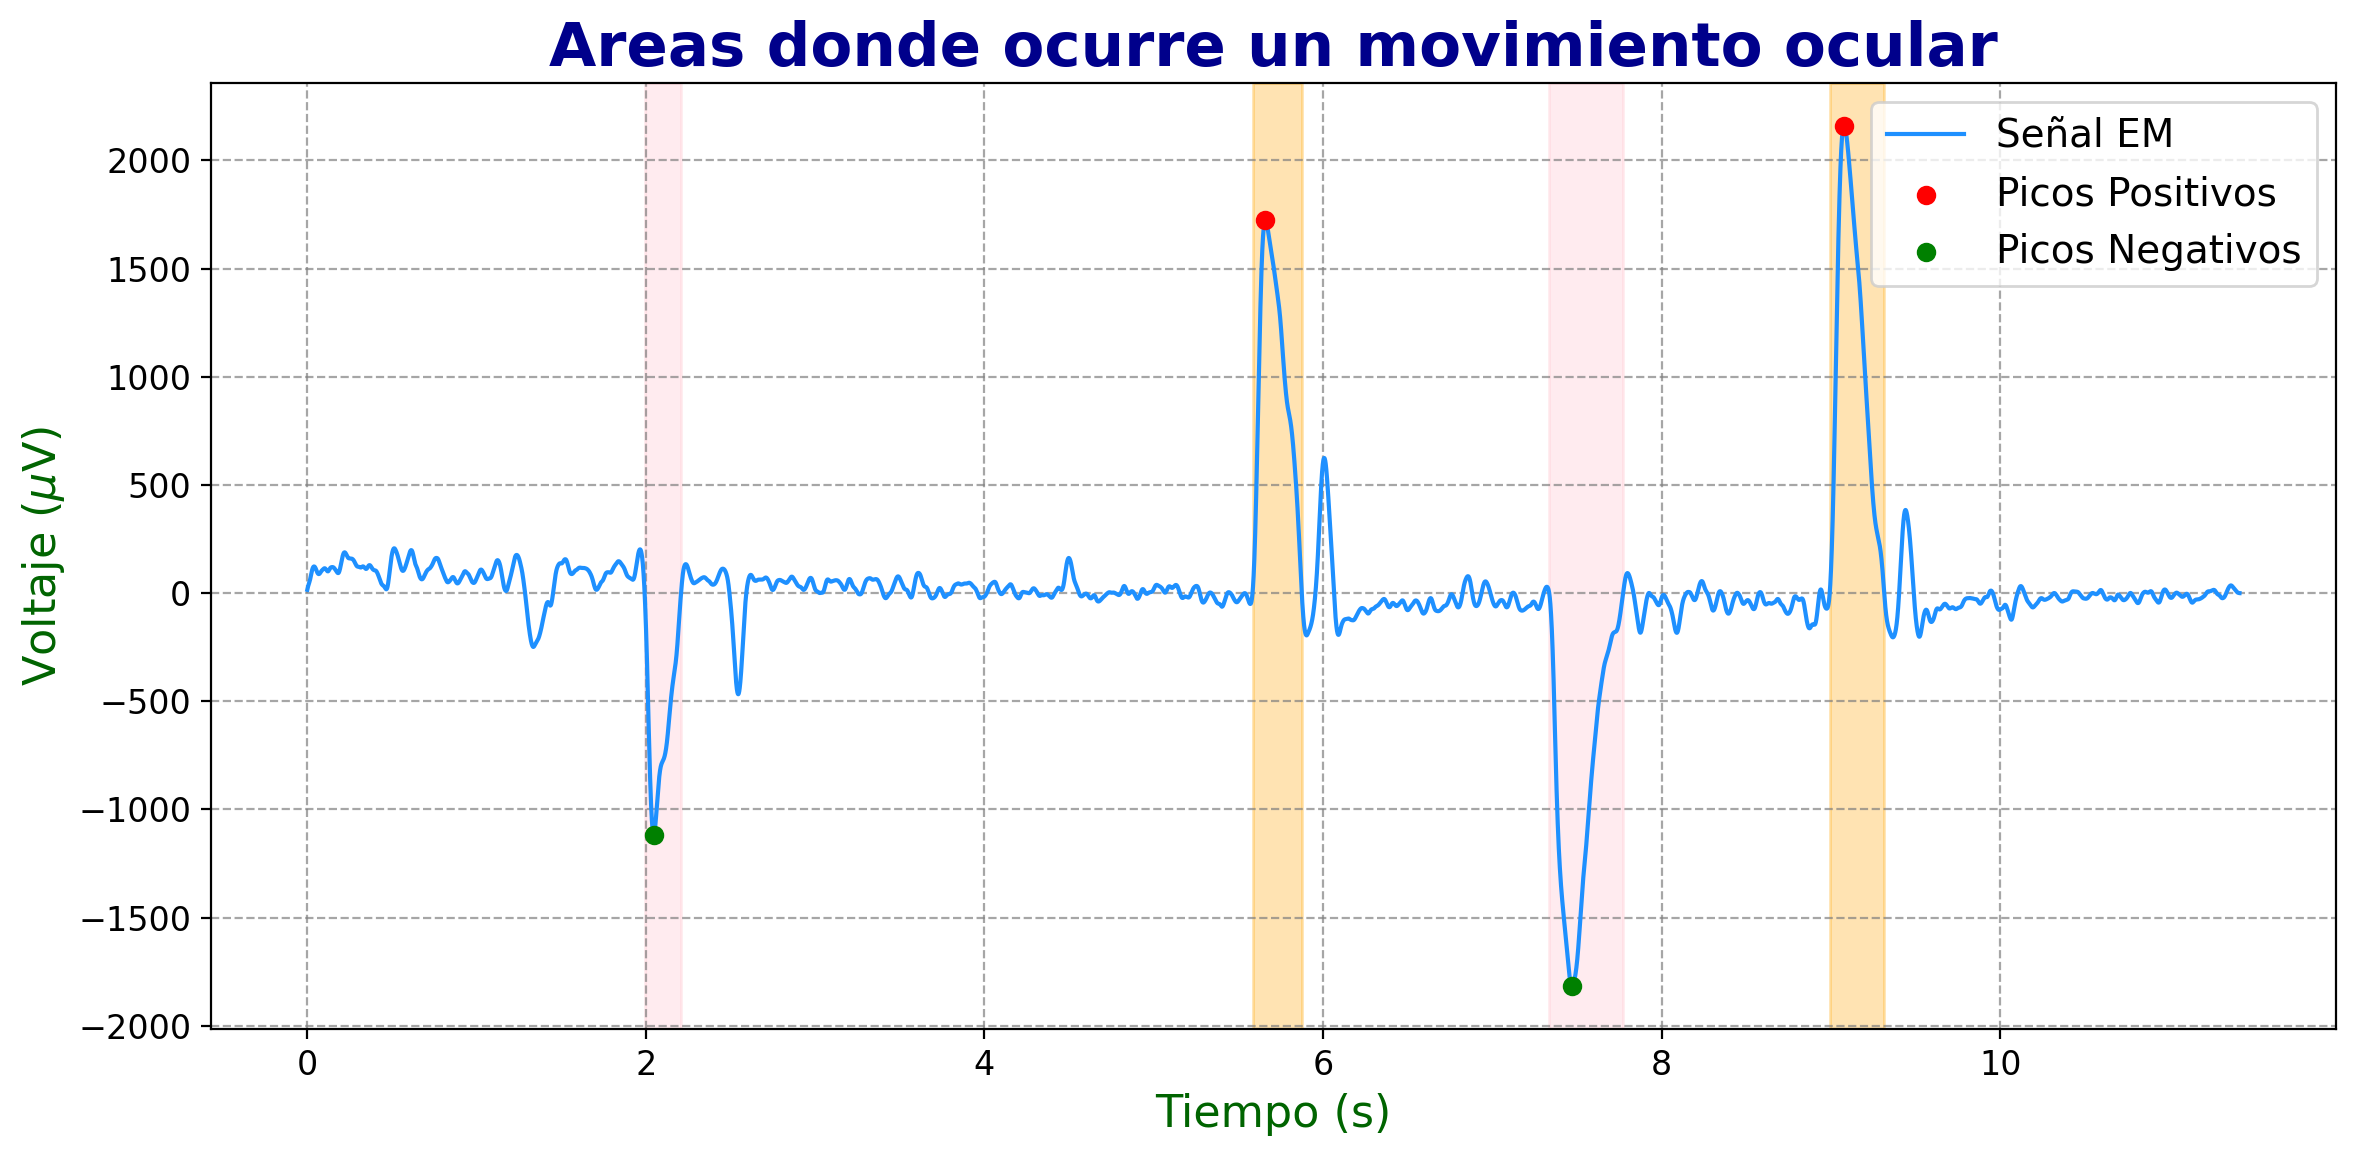

In [8]:
B=EOG_F.encontrar_bordes_vecindad_cero(picos_positivos=A[0], picos_negativos=A[1],P=20000, umbral=1200)

3.	Con las vecindades definidas, ahora es posible extraer información relevante asociada a cada movimiento ocular. A partir de estos intervalos, se obtienen parámetros clave como la amplitud, duración, velocidad y frecuencia de los movimientos, los cuales permiten caracterizar y clasificar los eventos presentes en el registro de manera más precisa.

    Además cabe resaltar que estos datos estan en función del voltaje no grados visuales.

In [9]:
C=EOG_F.analizar_movimientos_oculares_por_vecindad(bordes_positivos=B[0], bordes_negativos=B[1])

   Inicio (s)  Fin (s)  Amplitud (uV)  Duración (s)  Velocidad (uV/s)  \
0       1.993    2.208       1118.262         0.215          5198.757   
1       5.583    5.874       1724.101         0.291          5928.770   
2       7.336    7.772       1818.096         0.436          4166.087   
3       8.992    9.315       2160.966         0.322          6708.932   

   Frecuencia (Hz)  
0            0.000  
1            0.279  
2            0.571  
3            0.604  


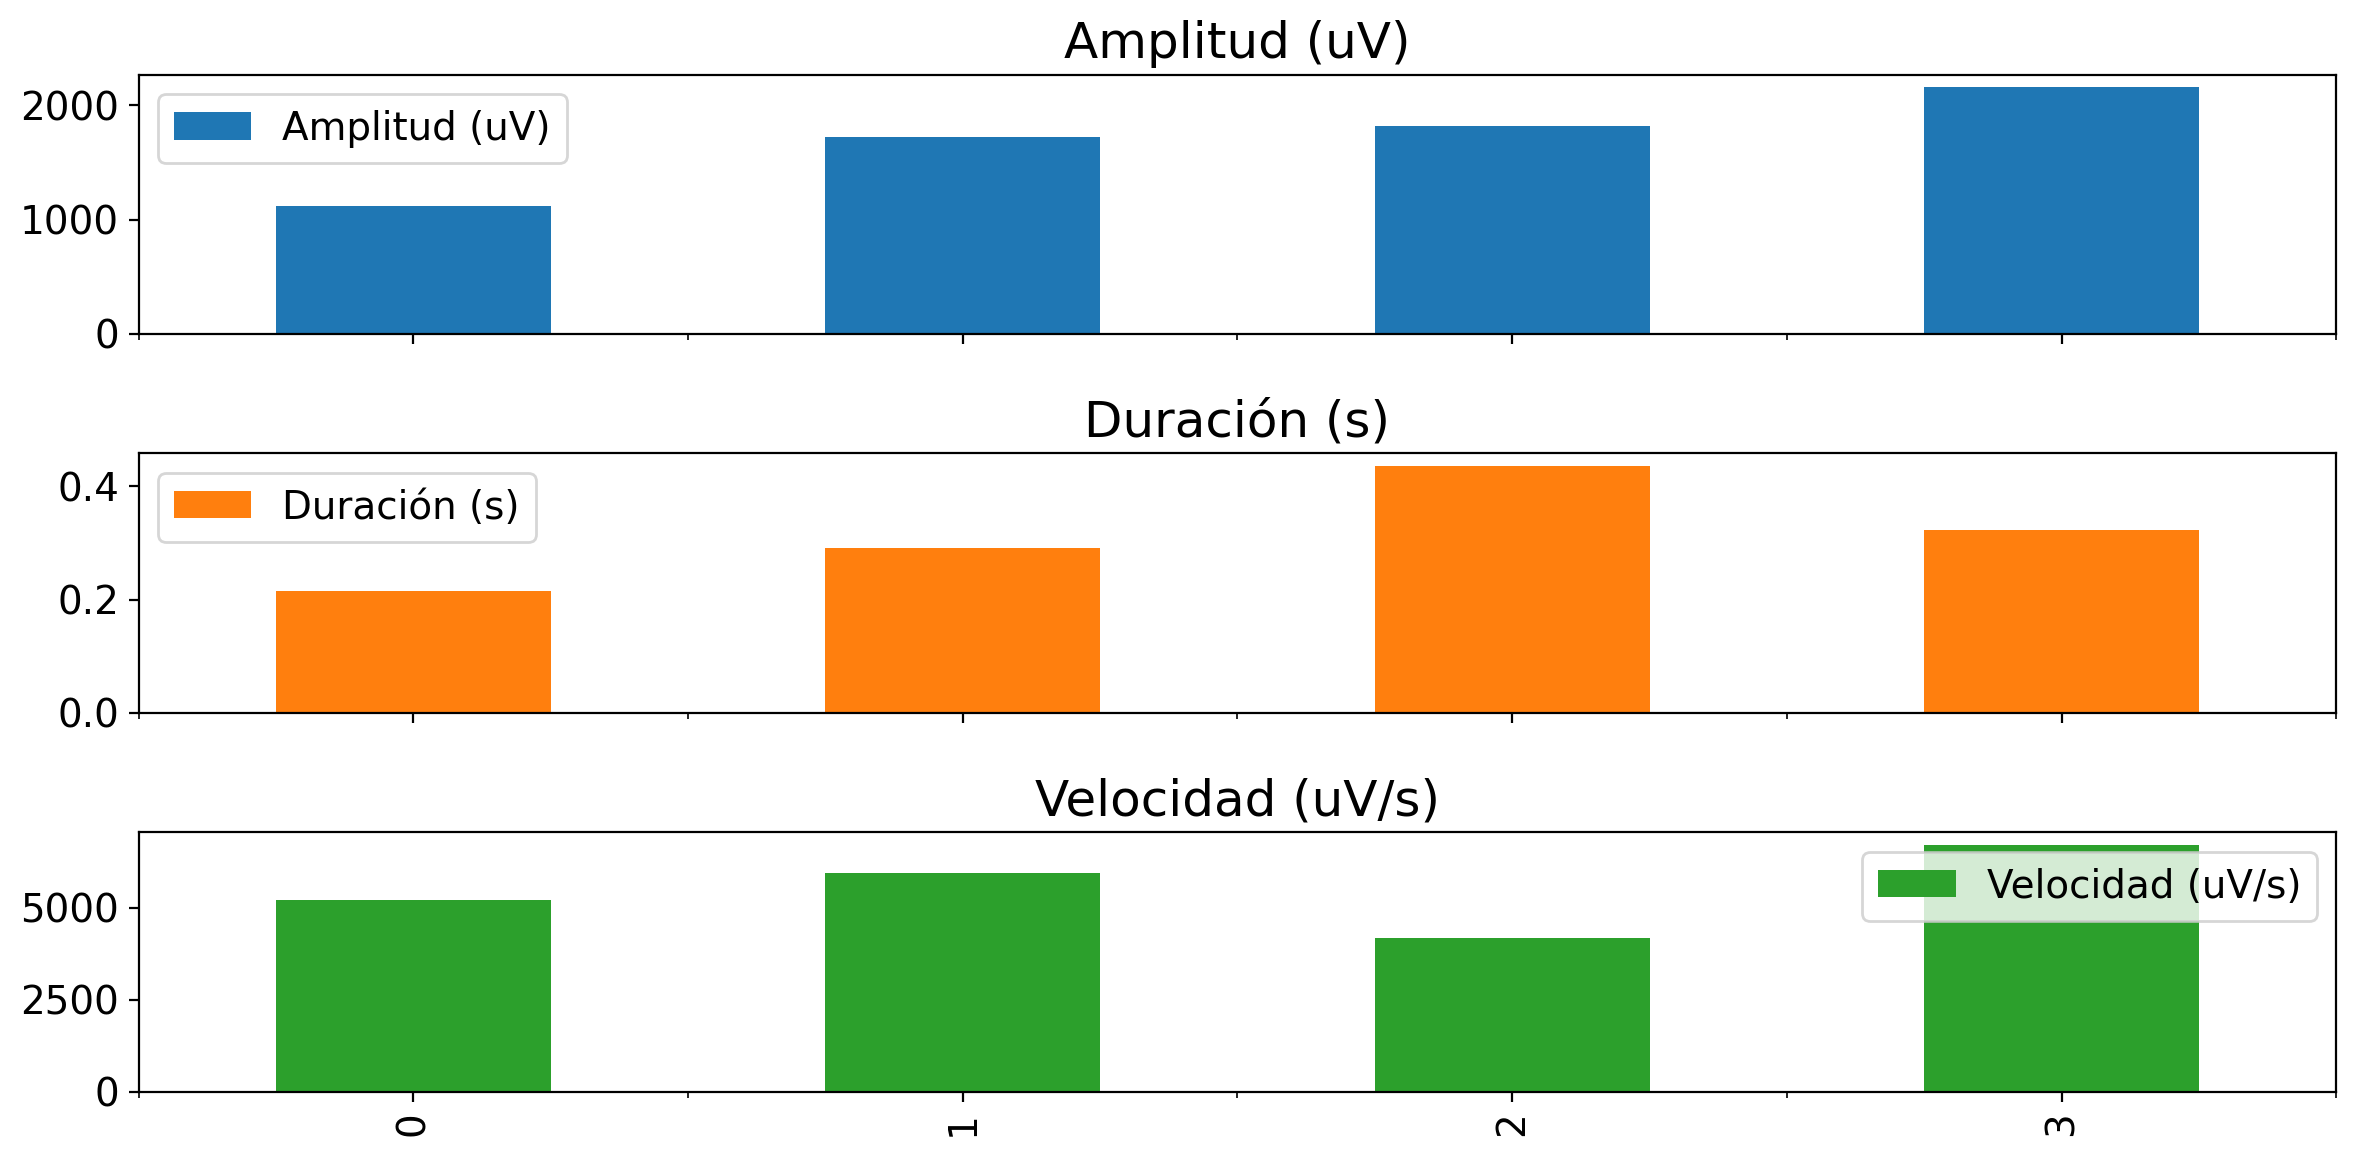

In [10]:
C.plot(kind='bar', y=['Amplitud (uV)', 'Duración (s)', 'Velocidad (uV/s)'], figsize=(12, 6), subplots=True)
plt.tight_layout()
plt.show()

4. A partir de los datos obtenidos en el paso anterior, se establece una clasificación heurística de los movimientos oculares. Esta clasificación se basa en umbrales definidos para variables como la amplitud, duración y velocidad, permitiendo distinguir entre distintos tipos de movimientos, tales como sacadas, microsacadas, fijaciones y parpadeos, de acuerdo con sus características fisiológicas y patrones observados en la señal.

##### Criterio Heuristico para la Clasificación de Movimientos Oculares (EOG)

| Tipo de Movimiento     | Condición (Amplitud, Duración, Velocidad)                  | Justificación |
|------------------------|-------------------------------------------------------------|---------------|
| **Sacada**             | Amplitud > 800 μV, Velocidad > 3500 μV/s, Duración ≤ 0.5 s  | Movimiento ocular rápido con cambio brusco de voltaje, típico de cambio de fijación visual. |
| **Microsacada**        | Amplitud < 800 μV, Duración < 0.08 s                        | Pequeños ajustes de la mirada, común durante fijaciones prolongadas. |
| **Fijación**           | Amplitud < 600 μV, Velocidad < 2000 μV/s, Duración ≥ 0.25 s | Período de estabilidad visual, el ojo permanece casi inmóvil captando información. |
| **Parpadeo**           | Amplitud > 2500 μV, Velocidad > 10000 μV/s, Duración < 0.4s     | Artefacto generado por cierre rápido de párpados, produce pico muy alto en EOG. |
| **Indefinido**         | No cumple ninguna de las condiciones anteriores             | Podría ser ruido o combinación atípica, requiere análisis más profundo. |

Conteo de tipos de movimientos:
Tipo de Movimiento
Sacada    4
Name: count, dtype: int64


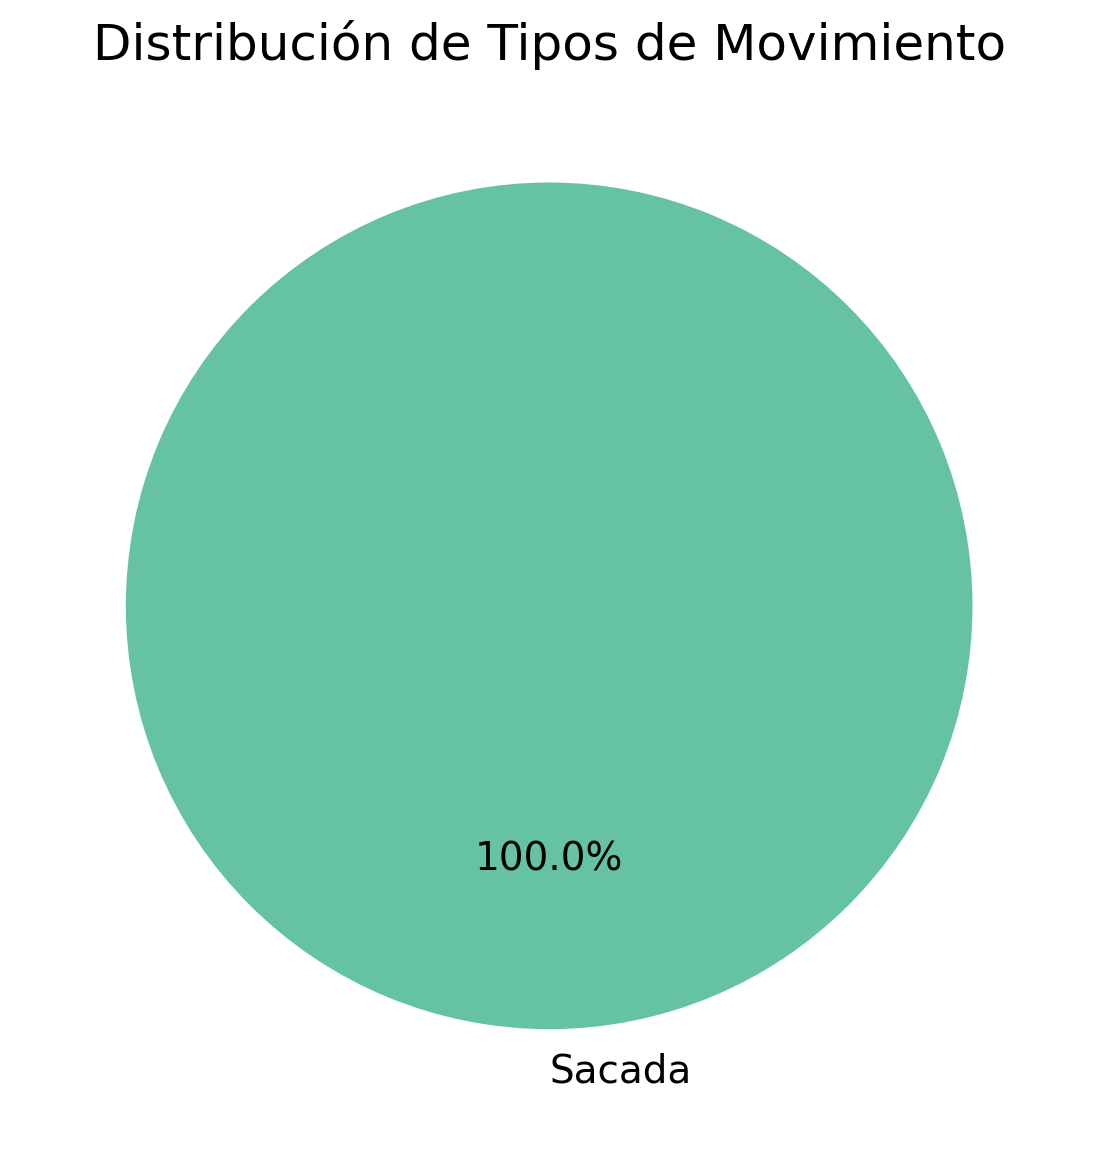

In [11]:
D=EOG_F.clasificar_y_visualizar_movimientos(C)

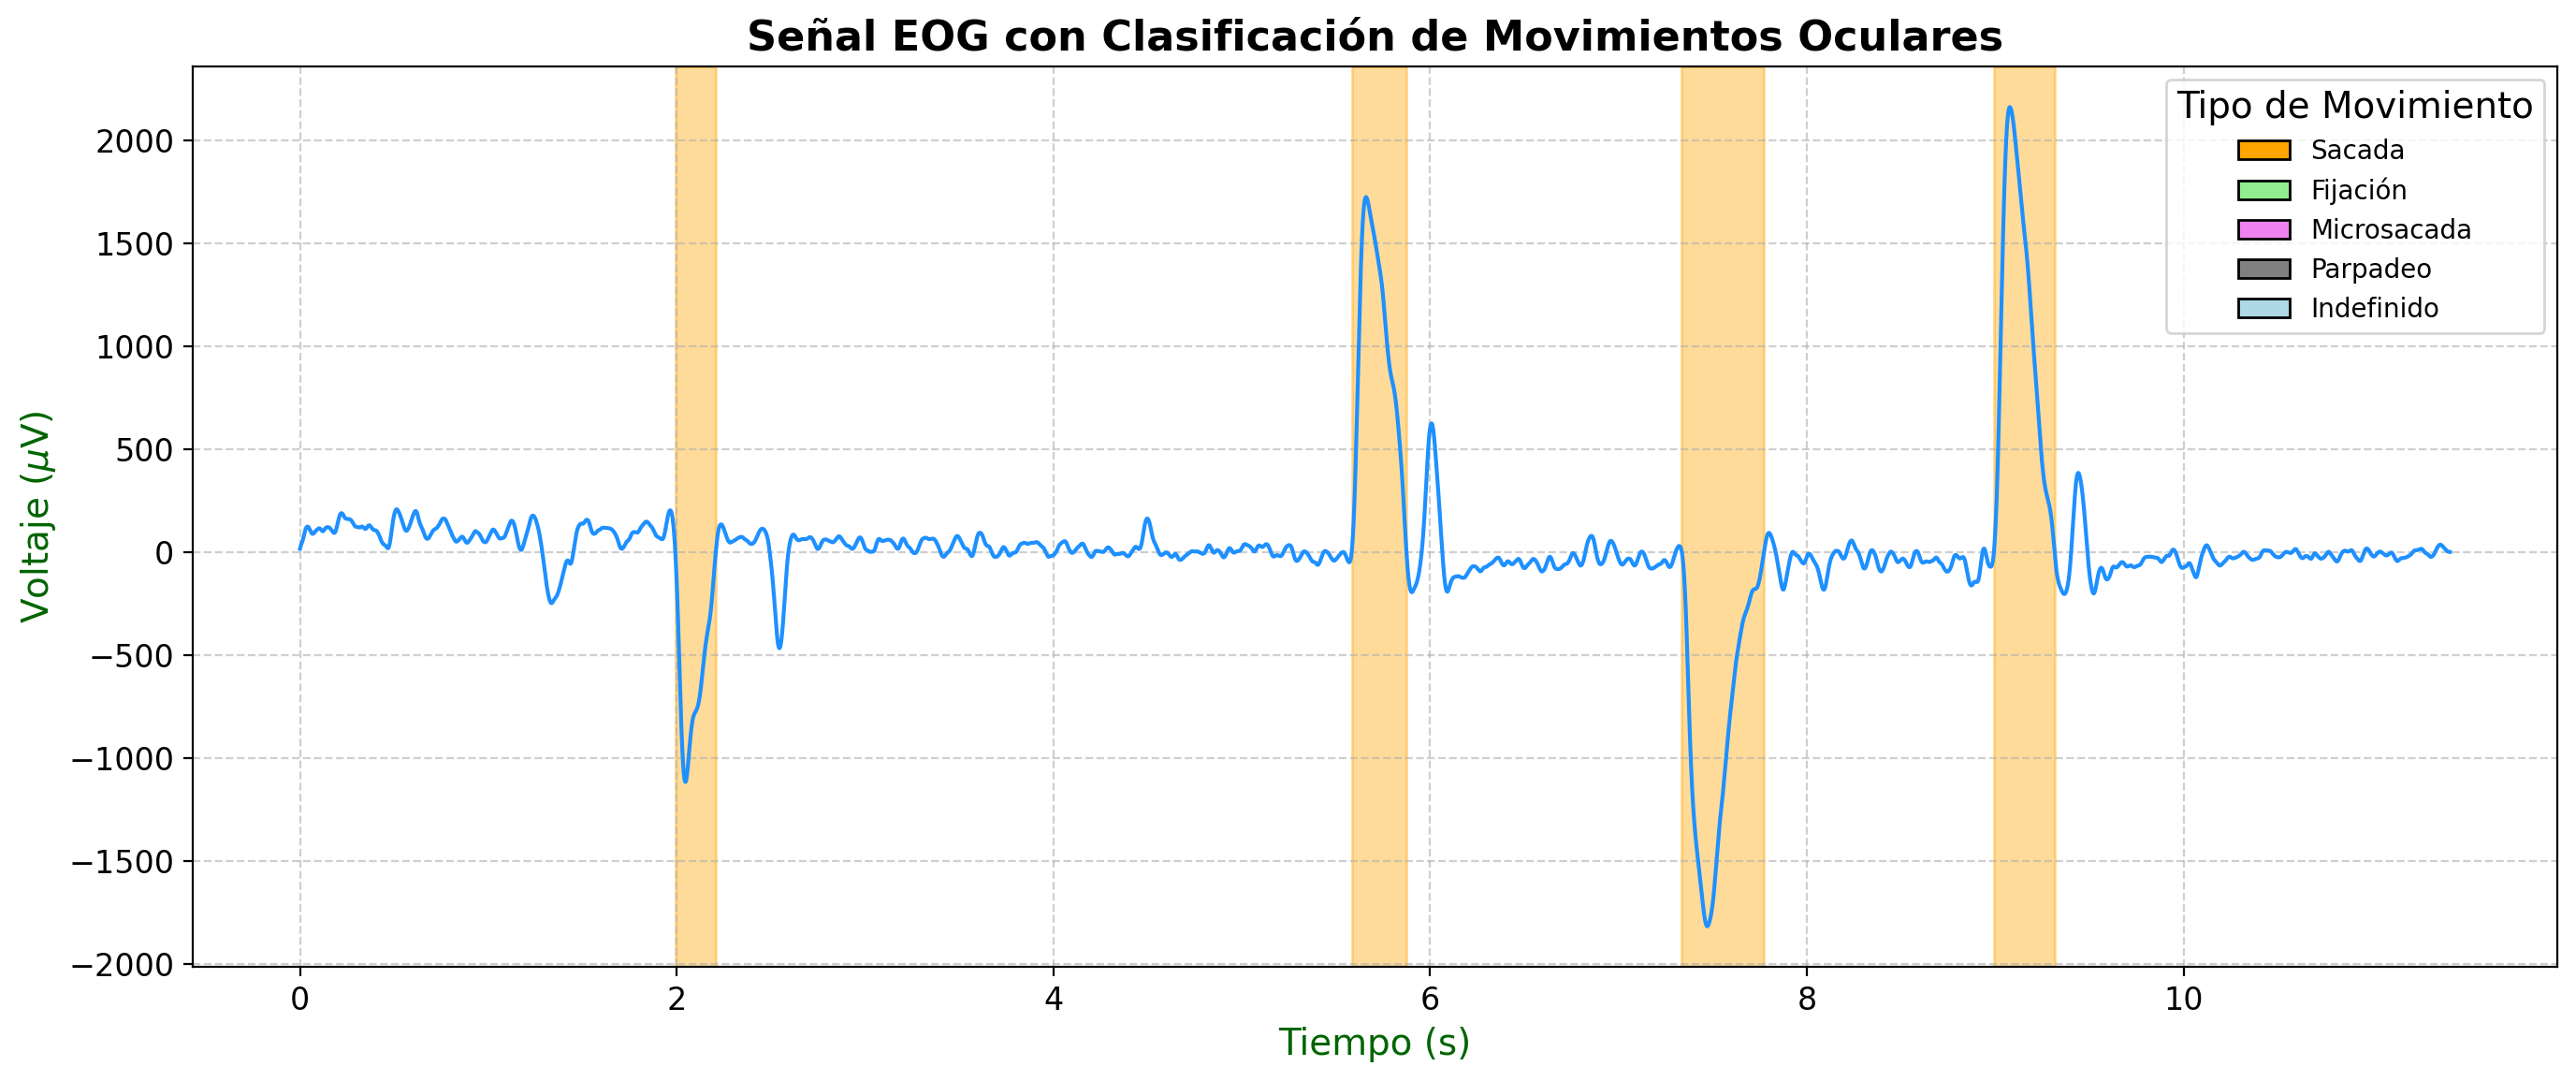

In [12]:
EOG_F.graficar_movimientos_clasificados(C)

5.	Una vez realizada la clasificación general de los movimientos oculares, surge una pregunta clave: ¿qué ocurre en los intervalos entre dichos movimientos? Para abordar esta cuestión, se implementaron métodos adicionales que permiten analizar los segmentos de señal comprendidos entre eventos clasificados, con el objetivo de identificar posibles fijaciones implícitas u otros patrones de comportamiento ocular relevantes.

In [13]:
E=EOG_F.agregar_fijaciones_entre_eventos(df_movimientos=D)

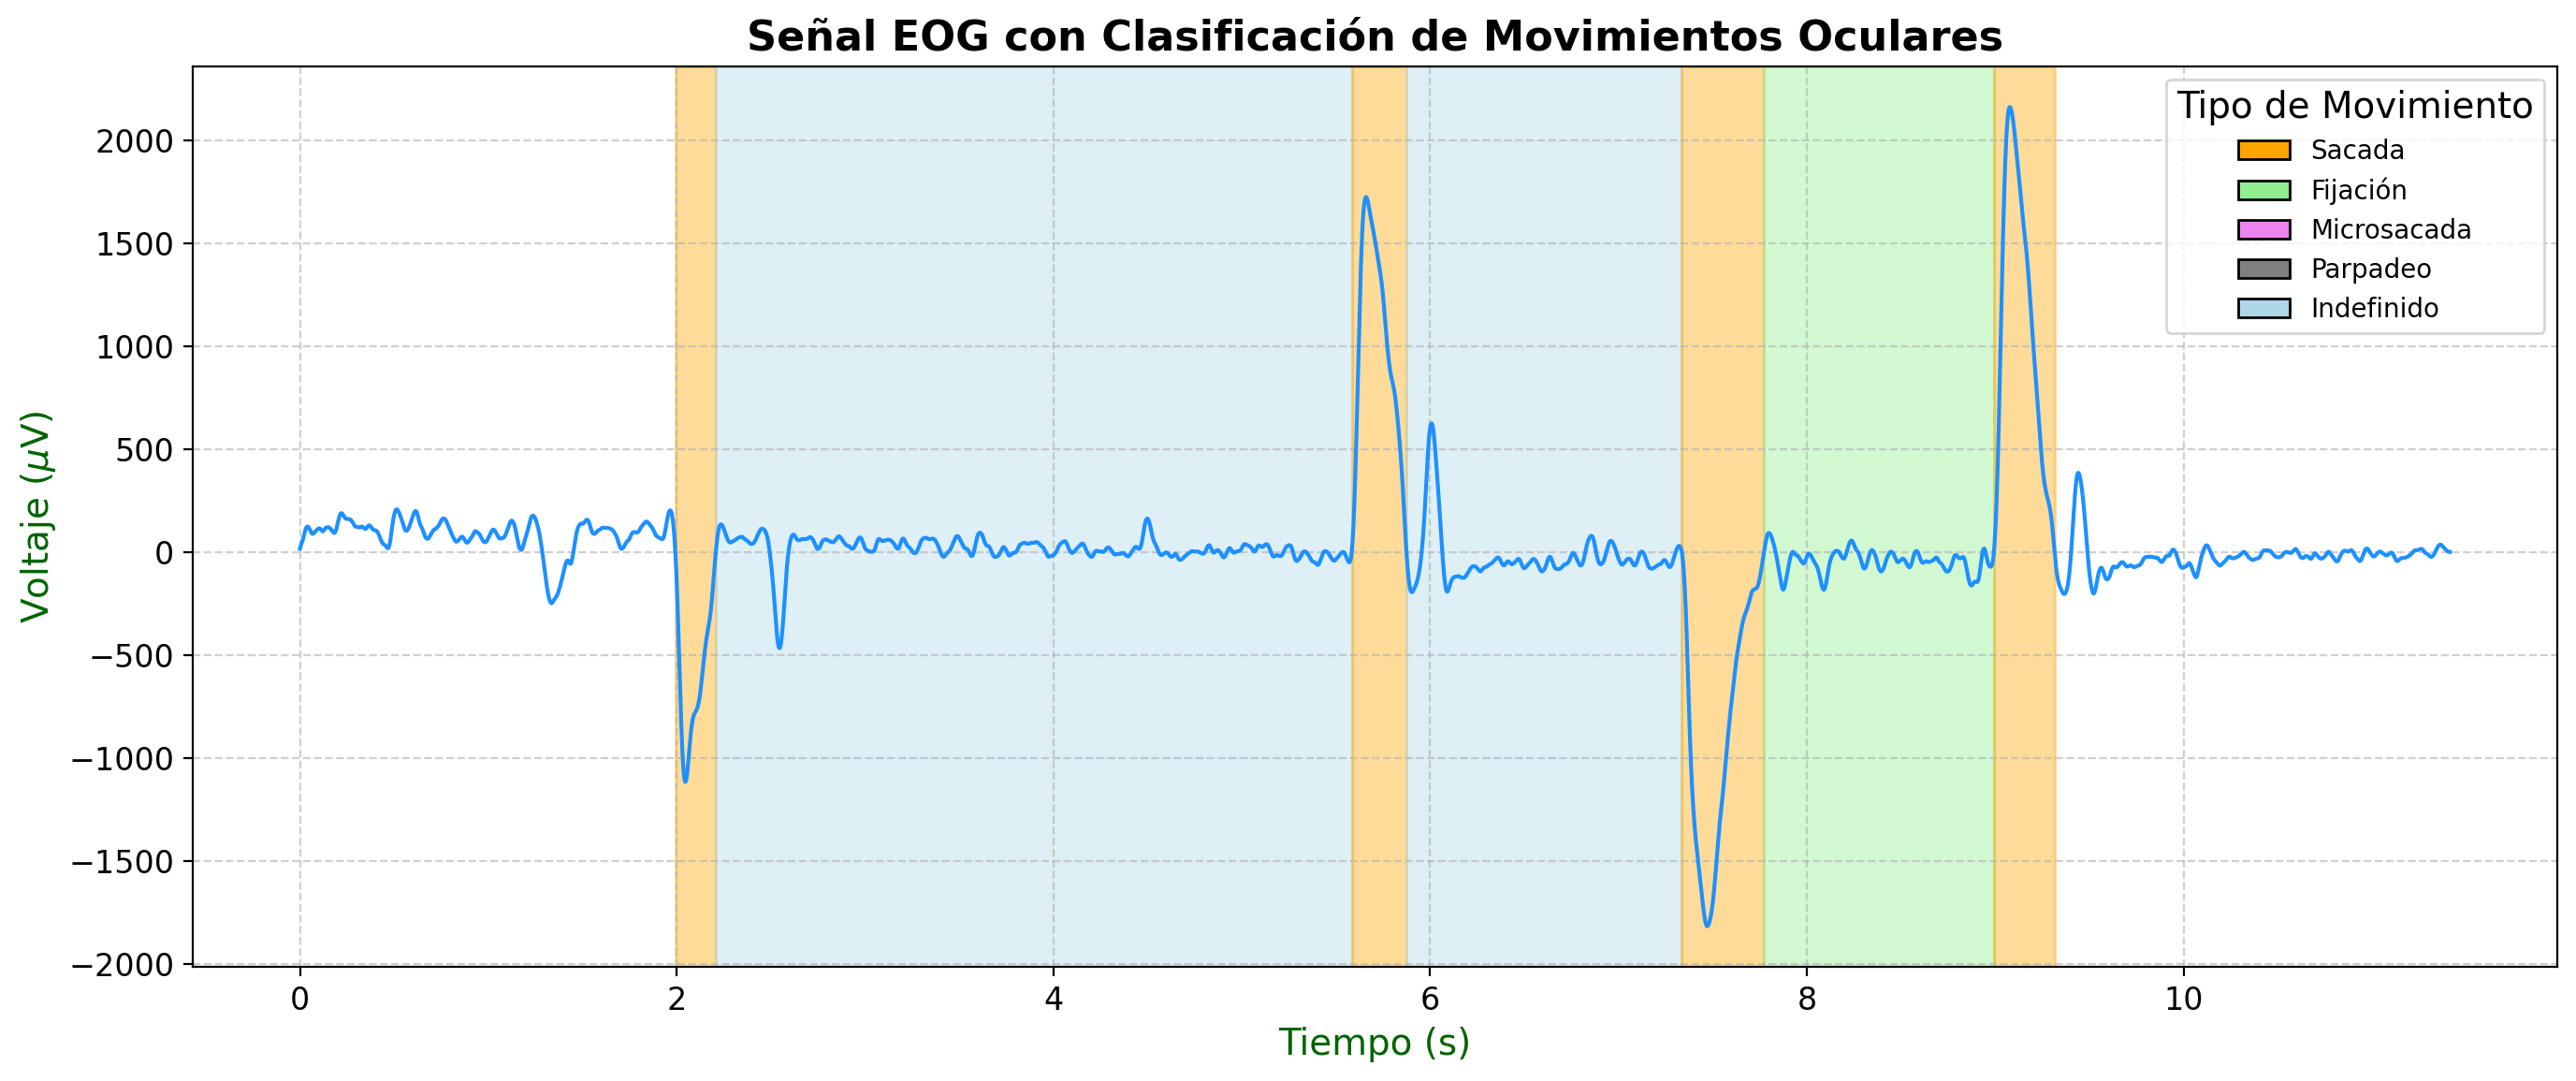

In [14]:
EOG_F.graficar_movimientos_clasificados(df=E)

A partir de la gráfica obtenida, observamos que dos de los tres intervalos entre sacadas fueron clasificados como “Indefinidos” según los criterios actuales. Sin embargo, esta clasificación probablemente se deba a la presencia de picos de amplitud considerable dentro de dichos intervalos, lo cual eleva los valores de velocidad y amplitud por encima de los umbrales establecidos para una fijación.

Es importante destacar que, si se relajaran ligeramente las condiciones del clasificador, particularmente los límites de amplitud y velocidad, estos intervalos podrían ser reconocidos como fijaciones, ya que corresponden a momentos donde la mirada permaneció relativamente estable tras el movimiento ocular.

<a id='R'></a>
### Resultados

Una vez realizado el análisis básico, ya estamos en condiciones de responder las preguntas planteadas al inicio del cuaderno:

    a) ¿Cómo podemos determinar la duración de los movimientos oculares?
    La duración se obtiene delimitando una vecindad alrededor de cada pico detectado. En este caso, utilizamos como criterio el cruce por cero (paso 2), lo que nos permite identificar el inicio y fin del movimiento. No obstante, también podrían definirse vecindades más complejas si se desea un análisis más preciso.

    b) ¿Cuánto tiempo transcurre entre un movimiento y otro?
    Este dato se obtiene midiendo la duración de los segmentos de señal entre vecindades consecutivas. Estos intervalos representan el tiempo en que la mirada permanece estable o fija antes de iniciar un nuevo movimiento.

    c) ¿Qué tan veloz fue el movimiento ocular?
    La velocidad se calcula como el cociente entre la amplitud y la duración del movimiento (velocidad = amplitud / duración). Aunque esta medida está en términos de voltaje (μV/s) y no en grados visuales, una velocidad alta puede interpretarse como un movimiento más brusco o rápido de los ojos.

Otras preguntas que podemos abordar con el análisis:

	•¿Cuál es la frecuencia de aparición de los movimientos oculares?
	•¿Cuál es la velocidad media y máxima registrada?
	•¿Cuál es la amplitud típica de las sacadas?
	•¿Qué porcentaje del tiempo total corresponde a fijaciones y cuánto a movimientos?
	•¿Existen anomalías o movimientos atípicos que no cumplen los patrones esperados?


Finalmente, es importante reflexionar sobre la confiabilidad de los eventos detectados. La presencia de movimientos clasificados como “Indefinidos” o el mal ajuste de los parámetros de clasificación podrían indicar la necesidad de ajustar los umbrales o aplicar técnicas de preprocesamiento adicionales para mejorar la precisión del análisis.